# 2025-cohort-homework
For this homework, we will use car fuel efficiency dataset to create a regression model for predicting the car fuel efficiency (column 'fuel_efficiency_mpg)
<br>
Q1. horsepower
<br>
Q2. 149
<br>
Q3. with mean
<br>
Q4. 0
<br> Q5. 0.006
<br> Q6. 0.506

In [2]:
data1 = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'

In [3]:
# !pip install wget

In [4]:
# !wget $data1

In [5]:

import pandas as pd
import numpy as np


In [6]:
df = pd.read_csv('car_fuel_efficiency.csv')
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [7]:
df.isnull().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [8]:
df['horsepower'].mean()

np.float64(149.65729212983547)

In [9]:
df['horsepower'].median()

np.float64(149.0)

In [10]:
np.random.seed(42)

In [11]:
idx = np.arange(len(df))
idx
np.random.shuffle(idx)
print(idx)

[ 483 7506 8795 ... 5390  860 7270]


In [12]:
df = df.iloc[idx]
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
483,220,3.0,144.0,2535.887591,18.7,2009,USA,Gasoline,All-wheel drive,2.0,16.642943
7506,160,2.0,141.0,2741.170484,14.3,2019,Asia,Diesel,Front-wheel drive,2.0,16.298377
8795,230,3.0,155.0,2471.880237,NaN,2017,Asia,Diesel,Front-wheel drive,2.0,18.591822
1688,150,3.0,206.0,3748.164469,15.5,2015,USA,Gasoline,All-wheel drive,1.0,11.818843
6217,300,4.0,111.0,2135.716359,16.9,2006,USA,Gasoline,All-wheel drive,NaN,19.402209


In [13]:
df.reset_index(drop=True)

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,220,3.0,144.0,2535.887591,18.7,2009,USA,Gasoline,All-wheel drive,2.0,16.642943
1,160,2.0,141.0,2741.170484,14.3,2019,Asia,Diesel,Front-wheel drive,2.0,16.298377
2,230,3.0,155.0,2471.880237,NaN,2017,Asia,Diesel,Front-wheel drive,2.0,18.591822
3,150,3.0,206.0,3748.164469,15.5,2015,USA,Gasoline,All-wheel drive,1.0,11.818843
4,300,4.0,111.0,2135.716359,16.9,2006,USA,Gasoline,All-wheel drive,NaN,19.402209
...,...,...,...,...,...,...,...,...,...,...,...
9699,210,2.0,163.0,1972.029124,14.4,2011,Europe,Diesel,All-wheel drive,1.0,19.961672
9700,160,4.0,126.0,3011.588014,16.4,2009,Europe,Diesel,All-wheel drive,-1.0,14.651056
9701,290,7.0,187.0,2440.508039,NaN,2019,USA,Gasoline,All-wheel drive,-1.0,18.404435
9702,260,2.0,129.0,1865.404480,14.5,2019,Europe,Gasoline,Front-wheel drive,0.0,20.502460


In [14]:
n = len(df)
n_train = int(n*0.6)
n_val = int(n*0.2)
n_test = n - n_train - n_val
n_train, n_val, n_test


(5822, 1940, 1942)

In [15]:
n

9704

In [16]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

## Train a linear regression model

In [17]:
def train_linear_regression(X,y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones,X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

## Baseline model

In [18]:
df_train.columns

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'num_doors', 'fuel_efficiency_mpg'],
      dtype='str')

In [19]:
df_train_filled_0 = df_train.copy()
df_train_filled_mean = df_train.copy()

In [20]:
df_train_filled_0['horsepower'] = df_train_filled_0['horsepower'].fillna(0)
df_train_filled_mean['horsepower'] = df_train_filled_mean['horsepower'].fillna(df_train['horsepower'].mean())

In [21]:
df_train.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [22]:
base = ['engine_displacement',
        'horsepower',
        'num_cylinders',
        'acceleration',
        'vehicle_weight',
        'model_year',
        'num_doors']
df_train[base]

,engine_displacement,horsepower,num_cylinders,acceleration,vehicle_weight,model_year,num_doors
483,220,144.0,3.0,18.7,2535.887591,2009,2.0
7506,160,141.0,2.0,14.3,2741.170484,2019,2.0
8795,230,155.0,3.0,NaN,2471.880237,2017,2.0
1688,150,206.0,3.0,15.5,3748.164469,2015,1.0
6217,300,111.0,4.0,16.9,2135.716359,2006,NaN
...,...,...,...,...,...,...,...
8387,160,111.0,2.0,12.1,3038.134712,2002,0.0
7331,160,157.0,NaN,18.4,2877.624938,2006,-1.0
1696,260,139.0,5.0,15.9,2606.972984,2009,-1.0
5685,280,132.0,4.0,12.8,4004.214323,2014,2.0


In [23]:
X_train = df_train[base].values
X_train

array([[ 2.20000000e+02,  1.44000000e+02,  3.00000000e+00, ...,
         2.53588759e+03,  2.00900000e+03,  2.00000000e+00],
       [ 1.60000000e+02,  1.41000000e+02,  2.00000000e+00, ...,
         2.74117048e+03,  2.01900000e+03,  2.00000000e+00],
       [ 2.30000000e+02,  1.55000000e+02,  3.00000000e+00, ...,
         2.47188024e+03,  2.01700000e+03,  2.00000000e+00],
       ...,
       [ 2.60000000e+02,  1.39000000e+02,  5.00000000e+00, ...,
         2.60697298e+03,  2.00900000e+03, -1.00000000e+00],
       [ 2.80000000e+02,  1.32000000e+02,  4.00000000e+00, ...,
         4.00421432e+03,  2.01400000e+03,  2.00000000e+00],
       [ 2.10000000e+02,  1.52000000e+02,  3.00000000e+00, ...,
         2.50017569e+03,  2.02000000e+03,  0.00000000e+00]],
      shape=(5822, 7))

In [24]:
X_train = df_train[base].fillna(0).values

In [25]:
y_train = df_train['fuel_efficiency_mpg'].values

In [26]:
w0,w=train_linear_regression(X_train,y_train)
w0,w

(np.float64(28.592348591868273),
 array([ 7.76439974e-05,  3.51827643e-03,  2.28850623e-04, -2.15787902e-02,
        -5.00555329e-03,  5.97369190e-04,  5.55734414e-03]))

In [27]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

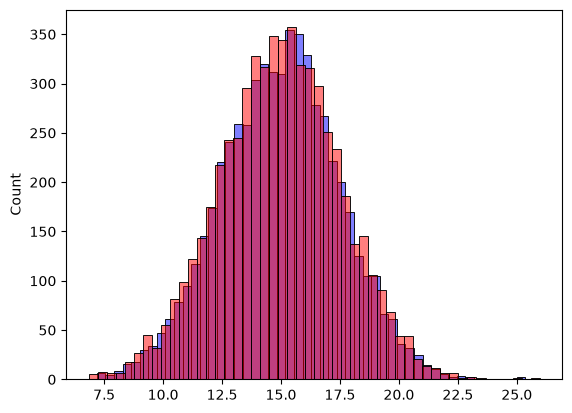

In [28]:
import seaborn as sns
sns.histplot(y_pred, bins = 50, color = 'blue', alpha = 0.5, label = 'predicted')
sns.histplot(y_train, bins = 50, color ='red', alpha = 0.5, label = 'actual')

RMSE

In [29]:
def rmse(y, y_pred):
    error = y -  y_pred
    se = error **2
    mse = se.mean()
    return np.sqrt(mse)

In [30]:
rmse(y_train, y_pred)

np.float64(0.5090440812579424)

In [31]:
X_train_mean = df_train[base].fillna(df_train[base].mean()).values

In [32]:
w0,w = train_linear_regression(X_train_mean, y_train)

In [33]:
y_pred1 = w0 + X_train_mean.dot(w)

In [34]:
rmse(y_pred1, y_train)

np.float64(0.3956629242661229)

Q4. train a regularized linear regression
fill the NAs with 0
which r gives the best RMSE?

In [35]:
X_train = df_train[base].fillna(0).values

In [36]:
import numpy as np
def train_linear_regression(X,y,r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones,X])

    XTX = X.T.dot(X)
    XTX = XTX + r*np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


In [37]:
r = 1
w0,w = train_linear_regression(X_train, y_train, r)
print(w0,w)
y_pred = w0 + X_train.dot(w)
rmse_temp = rmse(y_pred, y_train)

1.715972614953478 [ 0.00012534  0.00351813 -0.00019669 -0.02168163 -0.00499982  0.01394713
  0.00682649]


In [38]:
r_test = [0, 0.01, 0.1, 1, 5, 10, 100]
rmse_best = 10000
best_r = None
for r in r_test:
    w0,w = train_linear_regression(X_train, y_train, r)
    y_pred = w0 + X_train.dot(w)
    rmse_temp = rmse(y_pred, y_train)
    print(rmse_temp)
    if rmse_temp < rmse_best:
        rmse_best = rmse_temp
        best_r = r
    else:
        continue
best_r
    

0.5090440812579424
0.5092055356675661
0.512313814084275
0.5167662614162306
0.5175582391769608
0.517665709681471
0.5177641952774341


0

Q5. We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score
<br>
step 1: split data into train/validation/test split with 60%/20%/20% distribution 
<br>
step 2: fill the missing values with 0 and train the model with regularization
<br>
step 3: for each seed, evaluate the model on the validation dataset and collect RMSE scores
<br>step 4: compute the standard deviation of all the scores

In [39]:
seeds = np.arange(10)
seeds

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
rmses = np.array([])
for seed in seeds:
    np.random.seed(seed)
    idx = np.arange(len(df))
    np.random.shuffle(idx)
    ###
    n = len(df)
    n_train = int(n*0.6)
    n_val = int(n*0.2)
    n_test = n - n_train - n_val
    ###
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train+n_val:]]
    ###
    df_train.reset_index(drop=True)
    df_val.reset_index(drop=True)
    df_test.reset_index(drop=True)
    ###
    X_test = df_test[base].fillna(0).values
    y_test = df_test['fuel_efficiency_mpg'].values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']
    ###
    w0,w = train_linear_regression(X_train,y_train,r=0)
    w0,w
    ###
    rmse1 = rmse(y_test, w0+X_test.dot(w))
    ###
    rmses = np.append(rmses, rmse1)
print(rmses)
rmses.mean()
round(np.std(rmses),4)

[0.51233801 0.50867572 0.52025659 0.50763179 0.50873484 0.51733085
 0.49847076 0.5163792  0.50108052 0.50625574]


np.float64(0.0066)

Q6: 
split the dataset into 6:2:2, use seed 9
<br> combine train and validation datasets
<br> fill the missing values with 0 and train a model with r = 0.001
<br> What is the RMSE on the test dataset?

In [95]:
seed = 9
np.random.seed(seed)
idx = np.arange(len(df))
np.random.shuffle(idx)
###
n = len(df)
n_train = int(n*0.6)
n_val = int(n*0.2)
n_test = n - n_train - n_val
###
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]
###
df_train.reset_index(drop=True)
df_val.reset_index(drop=True)
df_test.reset_index(drop=True)
###
X_combined = pd.concat([df_train[base].fillna(0), df_val[base].fillna(0)]).values
y_combined = pd.concat([df_train['fuel_efficiency_mpg'],df_val['fuel_efficiency_mpg']]).values
X_test = df_test[base].fillna(0).values
y_test = df_test['fuel_efficiency_mpg'].values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
###
w0,w = train_linear_regression(X_combined,y_combined,r=0.001)
print(w0,w)
###
rmse1 = rmse(y_test, w0+X_test.dot(w))
print(round(rmse1,3))


28.903669675119858 [ 5.25211687e-05  3.50093690e-03 -8.82595803e-04 -2.10871193e-02
 -5.00711232e-03  4.48626196e-04  8.82018547e-03]
0.506
